# Modelling: Predicting PowerCo customer churn with a Random Forest

---

1. Import packages
2. Load data
3. Modelling (split, train, predict)
4. Evaluation
5. Feature importance
6. Is the model good enough? (answers to Estelle's questions)

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [9]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\data_for_predictions (1).csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
print(df.shape)
df.head()

(14606, 63)


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [10]:
# Quick sanity checks before modelling: missing values, data types and the size of the target classes
print('Missing values:', df.isna().sum().sum())
print(df.dtypes.value_counts())
print()
print(df['churn'].value_counts())
print('Churn rate: {:.1%}'.format(df['churn'].mean()))

Missing values: 0
float64    46
int64      16
object      1
Name: count, dtype: int64

churn
0    13187
1     1419
Name: count, dtype: int64
Churn rate: 9.7%


The dataset has no missing values, and apart from the `id` column all features are numeric, so a Random Forest can use them directly (no scaling needed). The target is **imbalanced**: only about 1 in 10 customers churned. This matters a lot for how we choose evaluation metrics.

---
## 3. Modelling

In [11]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling
We split the data into a training set (75%) and a test set (25%). The model only learns from the training set, and the test set simulates new, unseen customers so we can check that the model generalises. `random_state` makes the split reproducible.

In [12]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Churn share should be similar in both samples
print('Churn rate train: {:.1%} | test: {:.1%}'.format(y_train.mean(), y_test.mean()))

(10954, 61)
(10954,)
(3652, 61)
(3652,)
Churn rate train: 9.6% | test: 10.0%


### Model training
We train a Random Forest with **1000 trees** (`n_estimators=1000`). More trees make the vote more stable; the performance converges after a point, so 1000 is a safe choice. `n_jobs=-1` uses all CPU cores and `random_state=42` makes the result reproducible. Other parameters are left at defaults for this first baseline.

In [14]:
model = RandomForestClassifier(
    n_estimators=1000,   # number of decision trees in the forest
    random_state=42,     # reproducible results
    n_jobs=-1            # use all CPU cores
)
model.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---
## 4. Evaluation
We generate predictions for the test set. `predict` returns the final class (majority vote of the trees), and `predict_proba` returns the share of trees that vote for each class (a churn probability).

In [15]:
# Generate predictions here!
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]   # probability of churn (class 1)
predictions[:10], probabilities[:10].round(3)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0.105, 0.197, 0.048, 0.075, 0.038, 0.064, 0.022, 0.265, 0.016,
        0.043]))

In [16]:
# Calculate performance metrics here!
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

print('True negatives (stayed, predicted stay) :', tn)
print('False positives (stayed, predicted churn):', fp)
print('False negatives (churned, predicted stay):', fn)
print('True positives (churned, predicted churn):', tp)
print()
print('Accuracy : {:.3f}'.format(metrics.accuracy_score(y_test, predictions)))
print('Precision: {:.3f}'.format(metrics.precision_score(y_test, predictions)))
print('Recall   : {:.3f}'.format(metrics.recall_score(y_test, predictions)))
print('F1 score : {:.3f}'.format(metrics.f1_score(y_test, predictions)))
print('ROC AUC  : {:.3f}'.format(metrics.roc_auc_score(y_test, probabilities)))

True negatives (stayed, predicted stay) : 3283
False positives (stayed, predicted churn): 3
False negatives (churned, predicted stay): 349
True positives (churned, predicted churn): 17

Accuracy : 0.904
Precision: 0.850
Recall   : 0.046
F1 score : 0.088
ROC AUC  : 0.662


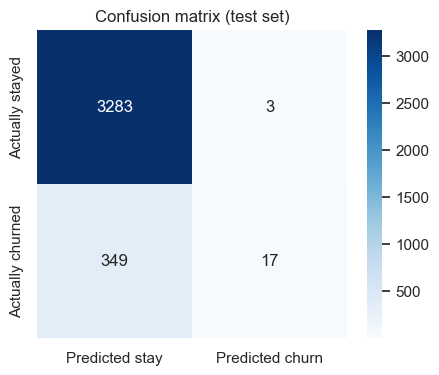

In [17]:
# Visualise the confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(metrics.confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted stay', 'Predicted churn'], yticklabels=['Actually stayed', 'Actually churned'])
ax.set_title('Confusion matrix (test set)')
plt.show()

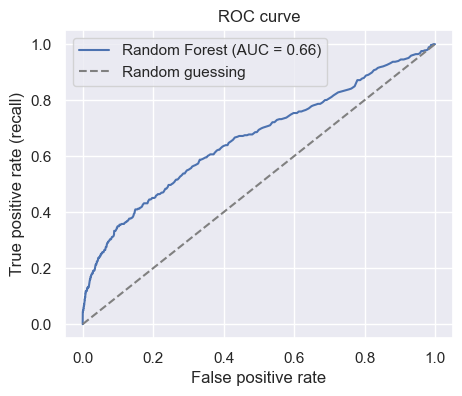

In [18]:
# ROC curve
fpr, tpr, _ = metrics.roc_curve(y_test, probabilities)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(metrics.roc_auc_score(y_test, probabilities)))
plt.plot([0, 1], [0, 1], '--', color='grey', label='Random guessing')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate (recall)')
plt.title('ROC curve'); plt.legend(); plt.show()

### Why these evaluation metrics?

**Accuracy** is the most intuitive metric but it is **misleading here**. Only ~10% of customers churn, so a model that predicts "no churn" for everyone would already score ~90% accuracy while finding zero churners. That is why we cannot rely on accuracy alone; we report it mainly to show this trap.

**Precision** (of the customers we flag as churners, how many really churn?) tells us how much retention budget would be wasted on customers who would have stayed anyway.

**Recall** (of all real churners, how many do we catch?) is the most important metric for PowerCo's business problem, because every churner we miss is lost revenue. Recall is where the model is judged.

**F1 score** combines precision and recall into one number and, unlike accuracy, is not inflated by the majority class.

**ROC AUC** measures how well the model *ranks* churners above non-churners across all possible decision thresholds (0.5 = random, 1.0 = perfect). It is independent of the 0.5 cut-off, so it tells us if the model has useful signal even if the default threshold is not ideal.

**Confusion matrix** shows exactly where the model is right and wrong, which makes the business cost of the errors visible.

### Results

- **Accuracy ~90%**: looks good, but it is only slightly better than the ~90% obtained by always predicting "stay".
- **Precision ~85%**: when the model says a customer will churn, it is usually right (but it says this very rarely).
- **Recall ~5%**: the model finds only about 17 of the 366 customers who actually churned in the test set, so it **misses ~95% of churners**.
- **F1 ~0.09** and **ROC AUC ~0.67**: confirm that the model is weak at identifying churners; the AUC shows only modest ranking ability.

### Can the decision threshold help?
By default a customer is labelled "churn" only if more than 50% of the trees vote churn. With imbalanced data the trees rarely reach 50%, so the model is very conservative. Lowering the threshold trades precision for recall. This does not need retraining.

In [19]:
rows = []
for t in [0.3, 0.2, 0.15, 0.1]:
    pred_t = (probabilities > t).astype(int)
    rows.append({'threshold': t,
                 'customers_flagged': pred_t.sum(),
                 'precision': metrics.precision_score(y_test, pred_t),
                 'recall': metrics.recall_score(y_test, pred_t),
                 'f1': metrics.f1_score(y_test, pred_t)})
pd.DataFrame(rows).round(3)

,threshold,customers_flagged,precision,recall,f1
0,0.30,155,0.426,0.180,0.253
1,0.20,485,0.268,0.355,0.306
2,0.15,864,0.196,0.462,0.275
3,0.10,1494,0.153,0.623,0.245


---
## 5. Feature importance
A Random Forest tells us which features it used most to split the data. This also gives a first answer to the price-sensitivity question: how much do price features matter compared with the others?

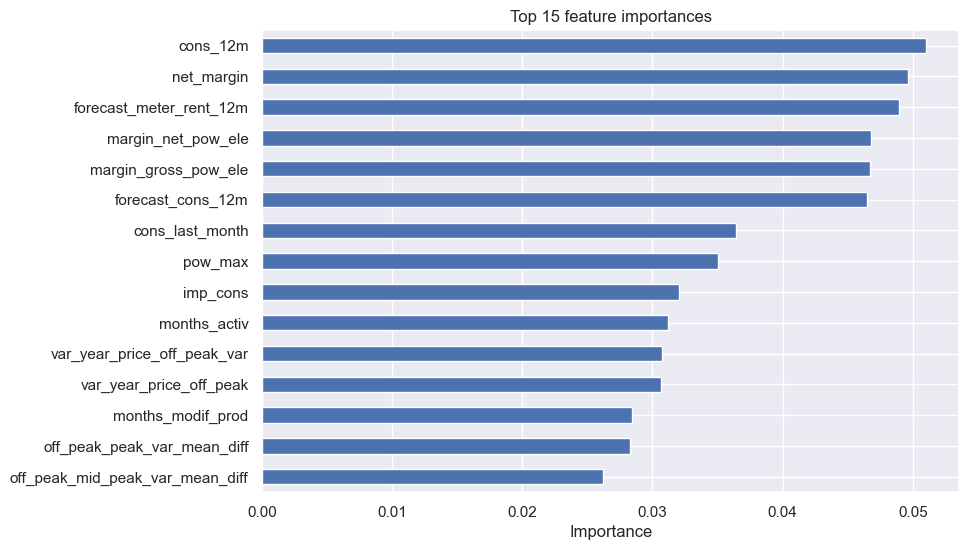

In [20]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)[::-1].plot(kind='barh', figsize=(9, 6), title='Top 15 feature importances')
plt.xlabel('Importance')
plt.show()

In [21]:
# Share of total importance by feature group
def group(c):
    if c.startswith(('var_', 'offpeak_diff', 'off_peak_', 'peak_mid', 'forecast_price')):
        return 'Price variables'
    if c.startswith(('months_', 'tenure')):
        return 'Contract / tenure'
    if c.startswith(('channel_', 'origin_')):
        return 'Channel / origin'
    return 'Consumption, margin & other'

importances.groupby(importances.index.map(group)).sum().sort_values(ascending=False).round(3)

Price variables                0.440
Consumption, margin & other    0.418
Contract / tenure              0.105
Channel / origin               0.038
dtype: float64

Price-related variables together carry a large share of the importance because there are many of them, but the **top individual features are consumption and margin variables**, not price changes. Importance is spread thinly over many features and no single price feature dominates. Note that feature importance shows what the model *uses*, not a causal effect, so this is supporting evidence only for the price-sensitivity hypothesis.

---
## 6. Is the model performance satisfactory?

**Short answer: no, not yet.**

**Justification**
1. **It misses almost all churners.** Recall is only ~5%: out of 366 real churners in the test set the model detects 17. Since the business goal is to *find customers who are about to leave*, this is the metric that matters, and it is far too low.
2. **High accuracy is an illusion.** ~90% accuracy is roughly what a model that never predicts churn would get, because ~90% of customers stay.
3. **Ranking ability is only modest.** ROC AUC of ~0.67 shows there is some signal in the data (better than random at 0.5) but not enough to be reliable.
4. **High precision is not very useful on its own.** The model is precise only because it flags a tiny number of customers (20 of 3,652).

**What we can say positively:** the model has learned some real pattern (AUC > 0.5), and lowering the threshold to ~0.2 catches about a third of churners with a precision of ~26% (2.6x better than picking customers at random, where only ~10% would be churners). That could already support a targeted retention campaign, depending on how much a retention offer costs versus the value of a retained customer.

**Suggested next steps to improve the model**
- Handle the class imbalance: `class_weight='balanced'` / `balanced_subsample`, or resampling (SMOTE, undersampling).
- Tune hyperparameters (`max_depth`, `min_samples_leaf`, `max_features`) with cross-validation, scoring on recall/F1/AUC instead of accuracy.
- Choose the decision threshold based on the business cost of a missed churner vs. a wasted offer.
- Try gradient boosting (XGBoost / LightGBM) and compare against this Random Forest baseline.
- Add more informative features (e.g. price gap versus competitors, customer service interactions) that PowerCo could provide.
- Use cross-validation to get more stable performance estimates than a single 75/25 split.

**Conclusion for the price-sensitivity hypothesis:** with the current features, price variables alone do not strongly explain churn (no price feature is at the top of the importance ranking), so the data does not yet support price being the single critical factor. A better-tuned model is needed before drawing a firm conclusion.